##### Copyright 2026 Google LLC.

In [1]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Gemini as a co-scientist: avian magnetoreception on a real quantum computer

<a target="_blank" href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/avian_magnetoreception.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" height=30/></a>

<!-- Community Contributor Badge -->
<table>
  <tr>
    <td bgcolor="#d7e6ff">
      <a href="https://github.com/steps-re" target="_blank" title="View steps-re on GitHub">
        <img src="https://github.com/steps-re.png?size=100" alt="steps-re GitHub avatar" width="100" height="100">
      </a>
    </td>
    <td bgcolor="#d7e6ff">
      <h2><font color='black'>This notebook was contributed by <a href="https://github.com/steps-re" target="_blank"><font color='#217bfe'><strong>steps-re</strong></font></a>.</font></h2>
    </td>
  </tr>
</table>

## Overview

Migratory birds cross oceans and continents and arrive within meters of where they
started a year earlier. The leading explanation for how they read Earth's magnetic
field is not an organ or a mineral. It is a quantum effect inside a protein in the
eye: the *radical-pair mechanism*.

In this notebook Gemini acts as a research partner. Gemini designs the quantum
circuit, you run it on a simulator and on IBM's real superconducting hardware, Gemini
interprets what came back, and then Gemini answers the question most demos avoid:
does this problem actually need a quantum computer at all?

The honest answer here turns out to be no, and working out why is the most useful
part of the notebook. It walks through multi-turn [system instructions](https://ai.google.dev/gemini-api/docs/text-generation#system-instructions),
structured technical reasoning, and a thinking model asked to make a genuinely hard
judgment against a concrete scientific artifact.

## The radical-pair mechanism

Light hits a cryptochrome protein in the bird's retina and knocks an electron from one
molecule to another. That leaves two unpaired electron spins, one on each molecule: a
*radical pair*. The pair is born in a quantum **singlet** state, where the two spins
are perfectly anti-correlated.

Left alone, the pair does not stay a singlet. The two spins coherently oscillate
between the singlet state and the three **triplet** states. Two things drive that
oscillation:

- the **Zeeman interaction** with Earth's magnetic field, and
- the **hyperfine interaction** with nearby atomic nuclei inside the molecule.

The chemistry that follows depends on whether the pair is a singlet or a triplet at the
moment it reacts, so the singlet-versus-triplet balance sets the amount of product the
reaction makes. Because the hyperfine coupling is **anisotropic** (it depends on
molecular orientation), that balance depends on the direction of the external field.
The protein becomes a chemical compass. The anisotropy is the whole trick. Remove it and
the direction sensitivity disappears.

> **In plain English.** Picture the two electrons as a pair of tiny spinning tops that
> start out perfectly in step. As they spin they drift in and out of step, and how fast
> they drift depends on which way the bird is facing in Earth's field. The bird's body
> turns that timing difference into a sense of direction. That is the whole compass.

## The model

You model the smallest honest version of this system: three spin-1/2 particles. Qubits 0
and 1 are the two electrons, prepared in a singlet. Qubit 2 is one hyperfine-coupled
nucleus. The energy rulebook (the Hamiltonian) is

$$
H \;=\; \underbrace{X_0X_2 + Y_0Y_2 + 3\,Z_0Z_2}_{\textstyle \text{hyperfine: electron 0 feels the nucleus}}
\;+\; \underbrace{B_x\,(X_0{+}X_1) + B_z\,(Z_0{+}Z_1)}_{\textstyle \text{Zeeman: both electrons feel Earth's field}}
$$

| symbol | what it is |
| :-- | :-- |
| `q0`, `q1` | the two electron spins, prepared as a singlet |
| `q2` | one nearby atomic nucleus |
| `Bx`, `Bz` | the sideways and vertical parts of the magnetic field |
| the 3 on `Z0Z2` | makes the coupling *anisotropic*, which is what creates direction sensing |

The observable is the **singlet survival probability** after a fixed time, swept over the
magnetic-field direction.

> **In plain English.** The formula above is just a rulebook for how the three spins push
> and pull on each other. The first group is one electron feeling its neighboring nucleus.
> The second is both electrons feeling Earth's field. Turn the field a different way and you
> change the push-and-pull, which changes the number you measure at the end.

The plan:

1. **Gemini designs the circuit** from the Hamiltonian and the observable.
2. You **build and run** it on a simulator, and check it against exact theory and against a
   real IBM hardware run of the same circuit.
3. You take one **step up** to a more realistic flavin model on hardware.
4. **Gemini interprets** the data.
5. **Gemini assesses** whether quantum hardware is actually needed here, honestly.

## Setup

### Install the SDKs

In [2]:
%pip install -U -q "google-genai>=2.9.0" "qiskit>=1.0" "qiskit-aer>=0.14" "qiskit-ibm-runtime>=0.20" matplotlib scipy
# google-genai>=2.9.0 for the Interactions API; qiskit for building and simulating
# the circuits. The optional live-hardware run also uses qiskit-ibm-runtime.

Note: you may need to restart the kernel to use updated packages.


### Set up your API key

To run the following cell, your API key must be stored in a Colab Secret named
`GEMINI_API_KEY`. If you don't already have an API key, or you're not sure how to create
a Colab Secret, see the [Authentication](https://github.com/google-gemini/cookbook/blob/main/quickstarts/Authentication.ipynb)
quickstart for a walkthrough.

In [3]:
from google.colab import userdata
from google import genai
from google.genai import types

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

Select the two models this notebook uses: a fast model for circuit design and
interpretation, and a stronger thinking model for the harder "do you even need a
quantum computer?" question at the end.

In [4]:
FAST_MODEL = "gemini-3.7-flash" # @param ["gemini-3.1-pro-preview", "gemini-3.7-flash", "gemini-3.5-flash-lite", "gemini-2.5-pro"] {"allow-input":true, isTemplate: true}DEEP_MODEL = "gemini-3.1-pro-preview" # @param ["gemini-3.1-pro-preview", "gemini-2.5-pro"] {"allow-input":true, isTemplate: true}

### Helpers and data

One small helper sends a single prompt with a system instruction through the Interactions
API and returns the reply text. The three hardware and benchmark result files are
pre-recorded so the whole notebook runs from a laptop, with no IBM Quantum account or
queue needed. They are openly licensed under Apache 2.0 with this notebook and download
from the cookbook repository.

In [5]:
# @title Setup: imports, the `ask_gemini` helper, and the pre-recorded data
import json
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display


def ask_gemini(prompt, system, model=FAST_MODEL):
    """Send one prompt with a system instruction and return the reply text."""
    interaction = client.interactions.create(
        model=model,
        input=prompt,
        system_instruction=system,
    )
    return interaction.steps[-1].content[0].text


# The pre-recorded IBM hardware and classical-benchmark results (a few KB of JSON each),
# openly licensed under Apache 2.0 with this notebook.
DATA = Path("data")
DATA.mkdir(exist_ok=True)
# Served from this notebook's own data/ folder in the cookbook repo. If the maintainers
# prefer, these three files can instead live at gs://generativeai-downloads/data/.
DATA_URL = "https://github.com/google-gemini/cookbook/raw/main/examples/data"
for _f in ("hardware_sweep.json", "compass_ladder_result_v2.json", "frontier_benchmark.json"):
    if not (DATA / _f).exists():
        urllib.request.urlretrieve(f"{DATA_URL}/{_f}", DATA / _f)

## Step 1: Gemini designs the circuit

Hand Gemini the Hamiltonian and the observable and ask for a concrete gate-level recipe:
how to prepare the singlet, how to Trotterize the time evolution, and how to measure
singlet survival in the computational basis.

In [6]:
DESIGN_SYSTEM = (
    "You are a quantum-computing co-scientist helping design a hardware experiment. "
    "Be concrete and correct about gate sequences. If a step is an approximation, say so. "
    "Keep the whole answer under about 500 words so no part is left unfinished. "
    "Format as Markdown that nests inside a notebook section: use bold labels or at most "
    "level-3 (###) headings, never level-1 (#) or level-2 (##), and no em-dashes. Write "
    "math as LaTeX ($...$ inline, $$...$$ display), but inside Markdown table cells use "
    "plain text or backticks, never LaTeX. If you use a table, keep every cell to a few "
    "words and put any longer explanation in prose beneath it, never full sentences inside "
    "cells. Keep literal gate sequences in code blocks."
)
DESIGN_PROMPT = """
    This experiment models the radical-pair mechanism of avian magnetoreception as three
    spin-1/2 particles. Qubits 0 and 1 are an electron pair born in a singlet; qubit 2 is
    one hyperfine-coupled nucleus. The Hamiltonian is
    H = X0X2 + Y0Y2 + 3*Z0Z2 + Bx*(X0+X1) + Bz*(Z0+Z1).
    The target observable is the survival probability of the electronic singlet after time
    t, as a function of the external field direction. Walk through building a Trotterized
    circuit:
    (1) how to prepare the two-electron singlet on qubits 0,1 from |00>;
    (2) how to decompose ONE Trotter step of exp(-i*H*dt) into standard gates
        (rzz/rxx/ryy or CX plus single-qubit rotations);
    (3) how to measure singlet-survival probability in the computational basis by applying
        the inverse singlet-prep before measurement so the |00> outcome projects onto the
        singlet.
    Give the concrete gate sequence for each part.
"""

design = ask_gemini(DESIGN_PROMPT, DESIGN_SYSTEM)
display(Markdown(design))

This experiment models the radical-pair mechanism using three spin-1/2 particles (qubits 0, 1, 2). Qubits 0 and 1 form an electron pair, initially in a singlet state, and qubit 2 represents a hyperfine-coupled nucleus. The Hamiltonian is $H = X_0X_2 + Y_0Y_2 + 3Z_0Z_2 + B_x(X_0+X_1) + B_z(Z_0+Z_1)$. We aim to build a Trotterized circuit to simulate its evolution and measure the singlet survival probability.

### 1. Singlet State Preparation on Qubits 0, 1

The goal is to prepare the electronic singlet state, $|S\rangle_{01} = \frac{1}{\sqrt{2}}(|01\rangle - |10\rangle)$, from the initial state $|00\rangle$.
The following gate sequence achieves this:
1.  Apply $X$ gates to qubits 0 and 1 to transform $|00\rangle$ to $|11\rangle$.
2.  Apply a Hadamard ($H$) gate to qubit 0. This transforms $|11\rangle$ to $\frac{1}{\sqrt{2}}(|01\rangle - |11\rangle)$.
3.  Apply a CNOT ($CX$) gate with qubit 0 as control and qubit 1 as target. This completes the transformation to the singlet state.

```
x 0
x 1
h 0
cx 0, 1
```

### 2. One Trotter Step Decomposition of exp(-i H dt)

A single Trotter step approximates the time evolution operator $U(dt) = \exp(-i H dt)$ as a product of exponentials of the individual Hamiltonian terms. This is a first-order Trotter approximation.

$U(dt) \approx e^{-i dt X_0X_2} e^{-i dt Y_0Y_2} e^{-i dt 3Z_0Z_2} e^{-i dt B_x X_0} e^{-i dt B_x X_1} e^{-i dt B_z Z_0} e^{-i dt B_z Z_1}$

Each term $\exp(-i \alpha P_j P_k)$ corresponds to a two-qubit Pauli rotation $R_{P_j P_k}(2\alpha)$, and $\exp(-i \alpha P_j)$ corresponds to a single-qubit Pauli rotation $R_{P_j}(2\alpha)$. The parameters $B_x$ and $B_z$ specify the strength of the external magnetic field.

The gate sequence for one Trotter step ($dt$) is:

```
# Two-qubit interactions
rxx(2*dt, 0, 2)
ryy(2*dt, 0, 2)
rzz(6*dt, 0, 2)  # Coefficient is 3, so angle is 2*3*dt = 6*dt

# Single-qubit interactions with external magnetic field Bx
rx(2*Bx*dt, 0)
rx(2*Bx*dt, 1)

# Single-qubit interactions with external magnetic field Bz
rz(2*Bz*dt, 0)
rz(2*Bz*dt, 1)
```

### 3. Measuring Singlet-Survival Probability

To measure the survival probability of the electronic singlet state after time $t$, we project the evolved state onto $|S\rangle_{01}$. This is done by applying the inverse of the singlet preparation circuit to qubits 0 and 1. If the state is still $|S\rangle_{01}$, this inverse circuit will transform it back to $|00\rangle$. We then measure qubits 0 and 1 in the computational basis. The probability of observing $|00\rangle$ on qubits 0 and 1 directly corresponds to the singlet survival probability $P_S = |\langle S | \psi(t) \rangle|^2$.

The inverse of the singlet preparation circuit ($X_0, X_1, H_0, CX_{01}$) is:

```
cx 0, 1
h 0
x 1
x 0
```
After applying these gates, measure qubits 0 and 1. The fraction of measurement outcomes where both qubits are in the $|0\rangle$ state gives the singlet survival probability.

> **In plain English.** You described the physics to Gemini and let it write the
> gate-by-gate recipe, the way you might ask a sharp TA to turn a textbook equation into
> step-by-step lab instructions.

## Step 2: Build the circuit

Here is the circuit that follows Gemini's recipe. The singlet you prepare is

$$|S\rangle \;=\; \tfrac{1}{\sqrt{2}}\big(|01\rangle - |10\rangle\big),$$

the "perfectly in step" state of the two electrons. Each Trotter step applies the
two-qubit hyperfine terms and the single-qubit field terms. Qiskit's rotation gates use the
convention $R_{PP}(\theta) = e^{-i\,(\theta/2)\,P\otimes P}$, so to apply one time slice
$e^{-i\,c\,P\otimes P\,\delta t}$ you set

$$\theta \;=\; 2\,c\,\delta t.$$

That factor of two is the one piece of bookkeeping that trips people up. The inverse prep
before measurement maps the singlet back to $|00\rangle$, so the probability of reading
`00` on qubits 0 and 1 is the singlet survival probability.

In [7]:
from qiskit import ClassicalRegister, QuantumCircuit
from qiskit.circuit import QuantumRegister
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator
from scipy.linalg import expm


def trotter_step(qreg, Bx, Bz, dt):
    """One first-order Trotter step of exp(-i*H*dt). R_P(theta) uses theta = 2*coeff*dt."""
    qc = QuantumCircuit(qreg)
    qc.rxx(2.0 * 1.0 * dt, qreg[0], qreg[2])
    qc.ryy(2.0 * 1.0 * dt, qreg[0], qreg[2])
    qc.rzz(2.0 * 3.0 * dt, qreg[0], qreg[2])
    qc.rx(2.0 * Bx * dt, qreg[0])
    qc.rx(2.0 * Bx * dt, qreg[1])
    qc.rz(2.0 * Bz * dt, qreg[0])
    qc.rz(2.0 * Bz * dt, qreg[1])
    return qc


def build_circuit(total_time, steps, Bx, Bz, measure=True):
    qreg = QuantumRegister(3, "q")
    qc = QuantumCircuit(qreg)
    # Singlet prep on q0, q1: |00> -> (|01> - |10>)/sqrt(2).
    qc.x(qreg[0])
    qc.x(qreg[1])
    qc.h(qreg[0])
    qc.cx(qreg[0], qreg[1])
    qc.barrier()
    dt = total_time / steps
    step = trotter_step(qreg, Bx, Bz, dt)
    for _ in range(steps):
        qc.compose(step, inplace=True)
    qc.barrier()
    # Inverse prep: maps the singlet back to |00> so '00' measures the singlet operator.
    qc.cx(qreg[0], qreg[1])
    qc.h(qreg[0])
    qc.x(qreg[0])
    qc.x(qreg[1])
    if measure:
        creg = ClassicalRegister(2, "c")
        qc.add_register(creg)
        qc.measure(qreg[0], creg[0])
        qc.measure(qreg[1], creg[1])
    return qc

Draw the circuit for one field setting with just 3 Trotter steps so it stays legible
(the real runs use 50).

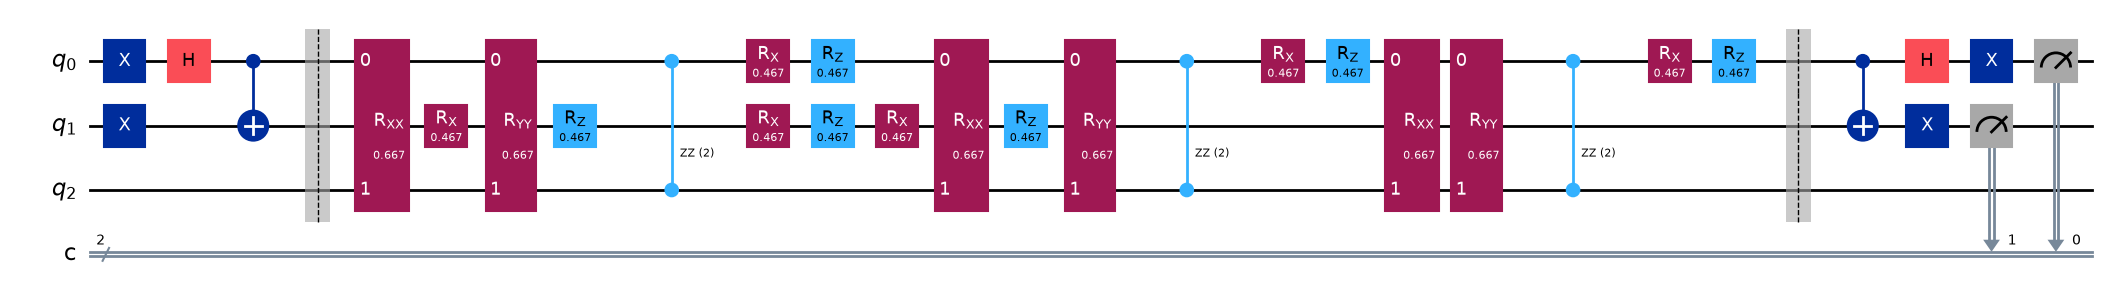

In [8]:
demo = build_circuit(total_time=1.0, steps=3, Bx=0.7, Bz=0.7)
display(demo.draw("mpl", fold=-1))

> **In plain English.** You chop the smooth, continuous evolution into 50 thin time slices
> and apply a few simple gates for each slice, the way many still frames add up to smooth
> motion.

## Step 3: Sweep the field angle

Hold the field magnitude fixed and rotate its direction, $\theta$ from 0 to $\pi$. At
each angle, run the circuit and read the singlet survival probability. Overlay three
things on one plot for the *same* single-nucleus model:

- the **exact** result from directly exponentiating $H$,
- the **simulator** (shot noise only), and
- a **real IBM hardware** run of these exact circuits (job `d94n6clgc6cc73ffas6g`,
  `ibm_kingston`, 1024 shots per angle), pre-recorded in `data/hardware_sweep.json`.

The observable is $P(\texttt{00})$ on qubits 0 and 1 with qubit 2 free, so the exact
projector sums over both nuclear states:

$$P_S(t) \;=\; \big|\langle S\,|\,\psi(t)\rangle\big|^2,
\qquad B_x = B\sin\theta,\;\; B_z = B\cos\theta.$$

In [9]:
def exact_singlet_survival(total_time, Bx, Bz):
    """Exact P(singlet on q0,q1) after continuous evolution, nucleus (q2) traced free."""
    H = SparsePauliOp.from_list(
        [
            ("XIX", 1.0),
            ("YIY", 1.0),
            ("ZIZ", 3.0),  # little-endian: leftmost = q0
            ("IIX", Bx),
            ("IXI", Bx),
            ("IIZ", Bz),
            ("IZI", Bz),
        ]
    )
    U = expm(-1j * total_time * H.to_matrix())

    def idx(q0, q1, q2):
        return q2 * 4 + q1 * 2 + q0

    psi0 = np.zeros(8, dtype=complex)
    psi0[idx(0, 1, 0)] = 1 / np.sqrt(2)
    psi0[idx(1, 0, 0)] = -1 / np.sqrt(2)
    psit = U @ psi0
    ps = 0.0
    for q2 in (0, 1):
        s = np.zeros(8, dtype=complex)
        s[idx(0, 1, q2)] = 1 / np.sqrt(2)
        s[idx(1, 0, q2)] = -1 / np.sqrt(2)
        ps += abs(np.vdot(s, psit)) ** 2
    return ps

Run the sweep on the simulator and against exact theory, then load the pre-recorded hardware run of the same circuits.

In [10]:
B_TOT, TOTAL_TIME, STEPS, SHOTS = 1.0, 1.0, 50, 4096
thetas = np.linspace(0.0, np.pi, 10)
sim = AerSimulator()

ps_sim, ps_exact = [], []
for theta in thetas:
    Bx, Bz = B_TOT * np.sin(theta), B_TOT * np.cos(theta)
    qc = build_circuit(TOTAL_TIME, STEPS, Bx, Bz)
    counts = sim.run(qc, shots=SHOTS, seed_simulator=42).result().get_counts()
    ps_sim.append(counts.get("00", 0) / SHOTS)
    ps_exact.append(exact_singlet_survival(TOTAL_TIME, Bx, Bz))

ps_sim, ps_exact = np.array(ps_sim), np.array(ps_exact)

# Pre-recorded real-hardware run of the SAME circuits (same thetas, |B|, time, steps).
hw = json.loads((DATA / "hardware_sweep.json").read_text())
ps_hw = np.array(hw["ps_hw"])

mae_sim = np.mean(np.abs(ps_sim - ps_exact))
mae_hw = np.mean(np.abs(ps_hw - ps_exact))
max_hw = np.max(np.abs(ps_hw - ps_exact))
display(
    Markdown(
        f"**Simulator vs exact theory:** mean absolute error {mae_sim:.4f}  \n"
        f"**Hardware vs exact theory:** mean absolute error {mae_hw:.4f} (worst angle {max_hw:.4f})"
    )
)

**Simulator vs exact theory:** mean absolute error 0.0056  
**Hardware vs exact theory:** mean absolute error 0.0147 (worst angle 0.0286)

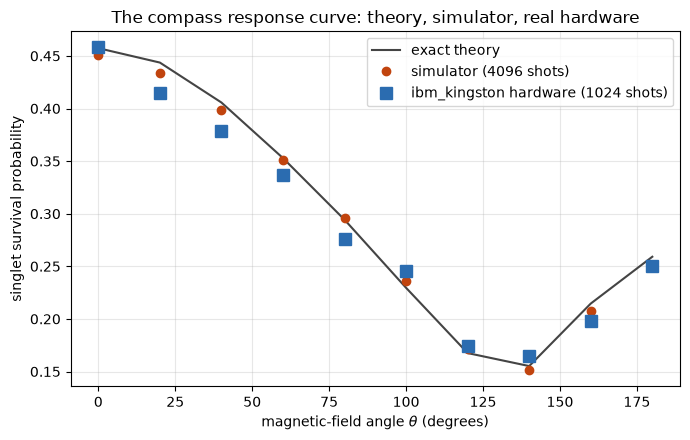

In [11]:
plt.figure(figsize=(7, 4.5))
plt.plot(np.degrees(thetas), ps_exact, "-", color="#444", label="exact theory")
plt.plot(np.degrees(thetas), ps_sim, "o", color="#c1440e", label=f"simulator ({SHOTS} shots)")
plt.plot(
    np.degrees(thetas),
    ps_hw,
    "s",
    color="#2b6cb0",
    markersize=8,
    label="ibm_kingston hardware (1024 shots)",
)
plt.xlabel(r"magnetic-field angle $\theta$ (degrees)")
plt.ylabel("singlet survival probability")
plt.title("The compass response curve: theory, simulator, real hardware")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

All three agree. The simulator tracks exact theory to within shot noise, and the real
`ibm_kingston` run follows the same curve to a mean absolute error of about 0.015 (worst
angle about 0.03). The singlet survival changes by roughly a factor of three across field
angles: that swing is the compass signal a bird's receptor would read out.

> **In plain English.** Rotating the field and watching how much of the original "in step"
> state survives traces the compass's response curve, and theory, simulator, and real hardware
> all agree.

## Step 4: A more realistic flavin model on hardware

The sweep above is the honest three-qubit toy: one nucleus, treated as spin-1/2. Below is a
**separate, more demanding experiment** on the same `ibm_kingston` processor. It is not the
same circuit as Step 3. It models the flavin radical with its real spin-1 nitrogen (N5)
hyperfine tensor, runs at 8192 shots with error mitigation (dynamical decoupling plus gate
and measurement twirling), and measures the **directional contrast** of the singlet yield,
the difference between field along and across the molecule.

It runs twice: once at today's field strength, and once at the much weaker field of the
Laschamp geomagnetic excursion. A working compass should show contrast today and lose it in
the weak field. The result below is pre-recorded in `data/compass_ladder_result_v2.json`
(job `d94t21cql68s73c9uod0`).

|  | Step 3 sweep | Step 4 flavin ladder |
| :-- | :-- | :-- |
| nucleus | one, spin-1/2 (toy) | real spin-1 nitrogen |
| varied | field **angle** | field **strength** |
| shots | 1024 | 8192 |
| error mitigation | none | dynamical decoupling + twirling |
| what it shows | the compass response curve | the compass switching on and off |

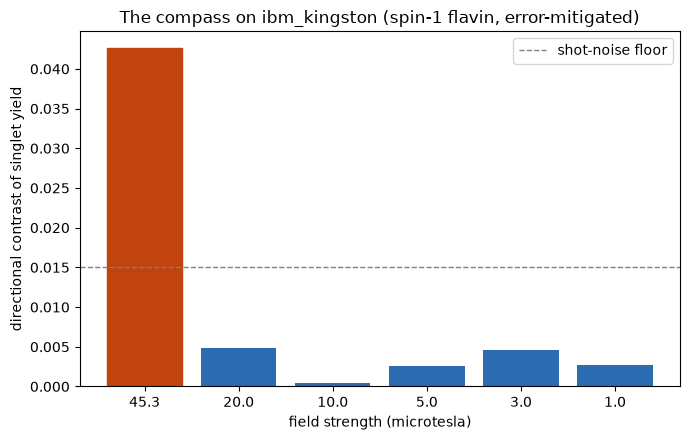

**Present-day field (45.3 uT):** contrast = 0.0426 (compass ON)  
**Laschamp weak field:** contrast = 0.0027 (compass OFF)  
**Contrast drop (present - weak):** 0.0399  
**Contrast ratio (present / weak):** 15.8x

In [12]:
ladder = json.loads((DATA / "compass_ladder_result_v2.json").read_text())

# JSON keys are field strengths as strings ("45.3", "20.0", ...); sort high to low.
keys = sorted(ladder["ladder"], key=float, reverse=True)
fields = [float(k) for k in keys]
aniso = [ladder["ladder"][k]["anisotropy"] for k in keys]

plt.figure(figsize=(7, 4.5))
bars = plt.bar([str(f) for f in fields], aniso, color="#2b6cb0")
bars[0].set_color("#c1440e")  # present-day Earth field
plt.axhline(0.015, ls="--", color="gray", lw=1, label="shot-noise floor")
plt.xlabel("field strength (microtesla)")
plt.ylabel("directional contrast of singlet yield")
plt.title("The compass on ibm_kingston (spin-1 flavin, error-mitigated)")
plt.legend()
plt.tight_layout()
plt.show()

display(
    Markdown(
        f"**Present-day field ({fields[0]} uT):** contrast = {ladder['present']:.4f} (compass ON)  \n"
        f"**Laschamp weak field:** contrast = {ladder['laschamp']:.4f} (compass OFF)  \n"
        f"**Contrast drop (present - weak):** {ladder['present'] - ladder['laschamp']:.4f}  \n"
        f"**Contrast ratio (present / weak):** {ladder['present'] / ladder['laschamp']:.1f}x"
    )
)

On real hardware the directional signal is clearly present at Earth's field strength and
collapses into the noise floor at the weak Laschamp field. The compass turns on and off
roughly where the physics says it should.

> **In plain English.** A more realistic stand-in for the molecule passes the real compass
> test, working at today's field and switching off when the field gets too weak.

### Optional: run the sweep on live hardware

To reproduce a hardware run yourself, set up an IBM Quantum account once and flip the flag
below. It is off by default so this notebook runs anywhere without hitting a queue.

In [13]:
RUN_ON_HARDWARE = False  # set True with a saved IBM Quantum account to submit the sweep live

if RUN_ON_HARDWARE:
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

    # One-time account setup (run once, then it is cached in ~/.qiskit):
    #   QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token="YOUR_IBM_TOKEN")
    service = QiskitRuntimeService()
    backend = service.least_busy(operational=True, simulator=False, min_num_qubits=3)
    print("backend:", backend.name)

    circuits = [
        build_circuit(TOTAL_TIME, STEPS, B_TOT * np.sin(t), B_TOT * np.cos(t))
        for t in thetas
    ]
    pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
    job = SamplerV2(mode=backend).run(pm.run(circuits), shots=SHOTS)
    print("job id:", job.job_id())

## Step 5: Gemini interprets the results

Give Gemini the simulator sweep next to the exact curve, plus the real-hardware error,
and ask it to separate physical signal from noise and say what the shape means for the
compass.

In [14]:
table = "theta_deg, P_singlet_sim, P_singlet_exact\n" + "\n".join(
    f"{d:.0f}, {s:.3f}, {e:.3f}"
    for d, s, e in zip(np.degrees(thetas), ps_sim, ps_exact, strict=False)
)
INTERP_SYSTEM = (
    "You are interpreting quantum-simulation output for a reader who codes but is not a "
    "physicist. Separate physical signal from noise. Be specific, not reassuring. "
    "Do not invent citations or attribute specific behavioral results to specific animal "
    "species; discuss the mechanism generally. Keep the answer under about 600 words. "
    "Format as Markdown that nests inside a notebook section: use bold labels or at most "
    "level-3 (###) headings, never level-1 (#) or level-2 (##), and no em-dashes. Write "
    "any math as LaTeX ($...$ inline, $$...$$ display), but inside Markdown table cells "
    "use plain text or backticks, never LaTeX. If you use a table, keep every cell to a "
    "few words and put any longer explanation in prose beneath it, never full sentences "
    "inside cells."
)
INTERP_PROMPT = f"""
    Here is a sweep of singlet-survival probability P_S versus magnetic-field angle theta
    (0 to 180 degrees), from a Trotterized quantum circuit ({SHOTS} shots per point),
    alongside the exact theoretical curve:
    {table}
    The circuit uses {STEPS} Trotter steps, so the Trotter discretization error is on the
    order of 1e-4 and negligible here; residuals at this shot count are dominated by shot
    noise.
    (1) What does the shape of P_S(theta) reveal about the chemical compass, and where is
        it most directionally sensitive?
    (2) Which features are physical signal versus shot noise?
    (3) The simulator tracks theory to a mean absolute error of about {mae_sim:.3f}. On real
        IBM hardware the same circuits matched theory to a mean absolute error of about
        {mae_hw:.3f} (worst angle about {max_hw:.3f}). What does that gap reveal about
        today's quantum hardware?
"""

display(Markdown(ask_gemini(INTERP_PROMPT, INTERP_SYSTEM)))

This output from a quantum simulation provides insight into how magnetic fields influence a chemical reaction's outcome and the current state of quantum hardware.

### Singlet-Survival Probability and Directional Sensitivity

The plot of $P_S(\theta)$ reveals how the probability of two spins remaining in a singlet state depends on the orientation of an external magnetic field. This angle-dependence is the core mechanism of a "chemical compass."

*   **Overall Shape:** The probability $P_S$ starts moderately high, decreases significantly as $\theta$ increases towards 100-120 degrees, and then rises again. This characteristic U- or V-shape is the physical signal. It indicates that the external magnetic field's alignment relative to an internal axis (implicitly defined by $\theta=0$ and $\theta=180$) profoundly affects the spin dynamics.
*   **Chemical Compass Mechanism:** In a radical pair mechanism, an external magnetic field can influence the rate at which electron spins interconvert between singlet (paired) and triplet (unpaired) states. This interconversion rate directly impacts the reaction's product yields. The shape of $P_S(\theta)$ shows that the field direction modulates this interconversion, changing the proportion of singlet states that survive.
*   **Most Directionally Sensitive Region:** The system is most sensitive to changes in magnetic field angle where the slope of $P_S(\theta)$ is steepest. Looking at the data, the largest changes in $P_S$ for a given $\Delta\theta$ occur roughly between $\theta=60^\circ$ and $\theta=120^\circ$. For example, $P_S$ drops from $0.353$ to $0.168$ between $60^\circ$ and $120^\circ$ (a change of $0.185$ over $60^\circ$), which is the most rapid average decrease. This suggests that these angles are where the chemical compass would be most effective at discerning subtle changes in field orientation.

### Physical Signal Versus Shot Noise

*   **Physical Signal:** The underlying smooth curve, represented by the `P_singlet_exact` data points, is the physical signal. This describes the true, deterministic dependence of singlet-survival probability on the magnetic field angle. The general trend captured by the `P_singlet_sim` points (decreasing then increasing) also represents the physical signal, albeit with superimposed noise.
*   **Shot Noise:** The small, random deviations of the `P_singlet_sim` values from the `P_singlet_exact` values at each angle are shot noise. For example, at $\theta=0$, `P_singlet_sim` is $0.451$ while `P_singlet_exact` is $0.457$. This difference of $0.006$ is a manifestation of shot noise. It arises because quantum circuits are probabilistic: each measurement (shot) yields one of many possible outcomes, and with a finite number of shots (here, 4096 per point), the estimated probability will fluctuate randomly around the true probability. Increasing the number of shots would reduce this noise, causing `P_singlet_sim` to converge closer to `P_singlet_exact`.

### Gap Between Simulator and Hardware

The mean absolute error (MAE) of $0.006$ for the simulator compared to $0.015$ (with a worst-case $0.029$) for real IBM hardware highlights the current limitations of quantum hardware.

*   **Simulator Performance:** The simulator's excellent agreement with theory (MAE $0.006$) confirms that the circuit design and Trotterization are essentially perfect for this problem, with residuals dominated by statistical shot noise. It represents the *ideal* performance one would expect from a perfectly noise-free quantum computer.
*   **Hardware Performance Gap:** The significantly larger error on real hardware (MAE $0.015$, more than double the simulator's error) indicates the presence of *additional noise sources and imperfections* beyond just shot noise. These include:
    *   **Coherence and Decoherence:** Real qubits interact with their environment, leading to a loss of quantum information (decoherence) over time. This limits the "depth" or complexity of circuits that can be reliably executed.
    *   **Gate Errors:** Imperfect calibration and implementation of quantum gates (e.g., rotations, controlled-NOT gates) introduce small but accumulating errors in the quantum state transformations.
    *   **Measurement Errors:** The process of reading out the final state of the qubits is not perfectly accurate.
    *   **Cross-talk:** Unwanted interactions between neighboring qubits can inadvertently affect their states.

This gap reveals that current quantum hardware (often termed "Noisy Intermediate-Scale Quantum" or NISQ) is susceptible to various forms of noise, preventing it from achieving the precision of error-corrected, fault-tolerant quantum computers. While impressive, these devices introduce systematic and random errors that are significantly larger than the statistical fluctuations from a finite number of measurements.

> **In plain English.** You hand the numbers back to Gemini as a skeptical lab partner to
> sort real signal from measurement noise.

## Step 6: Do you even need a quantum computer?

Quantum-biology demos usually stop here, at "look, it ran on a QPU." The more useful
question is whether a quantum computer is the *right tool* for this observable. The answer
turns out to be no, and understanding why is more valuable than the demo.

The catch with classical simulation is the nuclear-spin bath. A real cryptochrome has on
the order of 20 coupled nuclei. Brute-force **exact** simulation stores the full state
vector, whose size doubles with every nucleus, so it runs out of laptop memory around 10 to
11 nuclei. That looks like a wall a quantum computer should break.

But the observable that matters, the singlet yield, does not need the full state vector. A
**correlated-sampling typicality** estimator gets the same answer from a handful of random
states. Check it two ways below, both from real runs with a **fixed** sample count so the
comparison is clean:

- where exact simulation is still affordable ($N \le 10$), the estimator matches it, and
- its sample-to-sample spread keeps *shrinking* as the bath grows (a concentration-of-measure
  effect), so it stays reliable well past the point where exact simulation dies.

The two competing scalings are

$$\dim(\text{full state}) \;=\; 4\cdot 2^{N} \quad\text{(blows up)},
\qquad \text{typicality spread} \;\sim\; \frac{1}{\sqrt{\dim}} \quad\text{(shrinks)}.$$

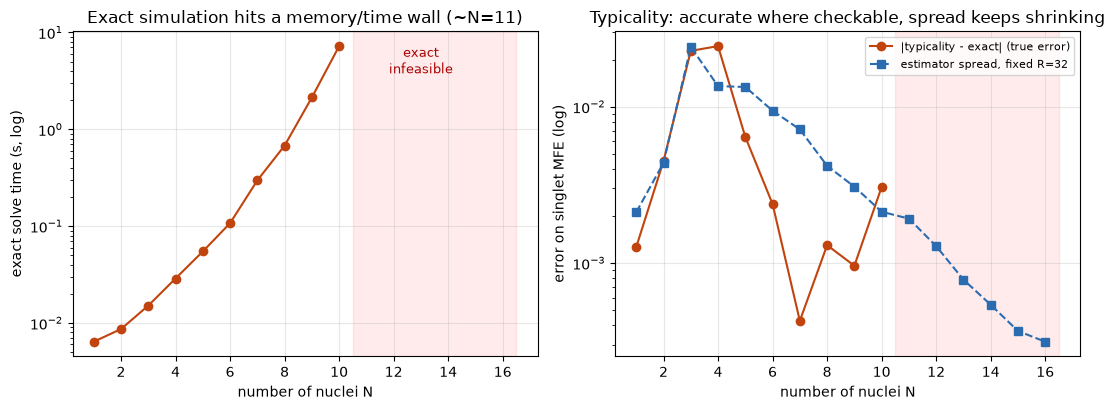

**Exact solve** becomes infeasible on a laptop beyond N~10 (state vector too large).  
**Typicality vs exact** where both exist (N<=10): worst error 0.0244.  
**Estimator spread** at fixed R=32: N=3 -> 0.0241, N=16 -> 0.0003 (shrinking).

In [15]:
fb = json.loads((DATA / "frontier_benchmark.json").read_text())
R = fb[0]["R"]

N = np.array([r["N"] for r in fb])
# Left panel: exact solve time explodes and stops at the memory wall.
Ne = [r["N"] for r in fb if r["exact_t"] is not None]
Te = [r["exact_t"] for r in fb if r["exact_t"] is not None]
# Right panel: true accuracy where checkable, plus the estimator's own spread everywhere.
Nacc = [r["N"] for r in fb if r["typ_vs_exact"] is not None]
acc = [r["typ_vs_exact"] for r in fb if r["typ_vs_exact"] is not None]
spread = [r["typ_err"] for r in fb]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
a1.semilogy(Ne, Te, "o-", color="#c1440e")
a1.axvspan(10.5, N.max() + 0.5, color="red", alpha=0.08)
a1.text(13, max(Te), "exact\ninfeasible", color="#a00", ha="center", va="top", fontsize=9)
a1.set_xlabel("number of nuclei N")
a1.set_ylabel("exact solve time (s, log)")
a1.set_title("Exact simulation hits a memory/time wall (~N=11)")
a1.grid(alpha=0.3)

a2.semilogy(Nacc, acc, "o-", color="#c1440e", label="|typicality - exact| (true error)")
a2.semilogy(N, spread, "s--", color="#2b6cb0", label=f"estimator spread, fixed R={R}")
a2.axvspan(10.5, N.max() + 0.5, color="red", alpha=0.08)
a2.set_xlabel("number of nuclei N")
a2.set_ylabel("error on singlet MFE (log)")
a2.set_title("Typicality: accurate where checkable, spread keeps shrinking")
a2.legend(fontsize=8)
a2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

worst_acc = max(acc)
display(
    Markdown(
        f"**Exact solve** becomes infeasible on a laptop beyond N~{Ne[-1]} (state vector too large).  \n"
        f"**Typicality vs exact** where both exist (N<={Nacc[-1]}): worst error {worst_acc:.4f}.  \n"
        f"**Estimator spread** at fixed R={R}: N=3 -> {spread[2]:.4f}, N={N[-1]} -> {spread[-1]:.4f} (shrinking)."
    )
)

Hand the benchmark to a skeptical thinking model and ask for an honest verdict on quantum advantage for this observable.

In [16]:
INTERP2_SYSTEM = (
    "You are a skeptical computational physicist. Do not flatter quantum computing. "
    "If a classical method wins, say so plainly and explain why. Keep the answer under "
    "about 600 words so no section is cut off. "
    "Format as Markdown that nests inside a notebook section: use bold labels or at most "
    "level-3 (###) headings, never level-1 (#) or level-2 (##), and no em-dashes. Write "
    "any math as LaTeX ($...$ inline, $$...$$ display), but inside Markdown table cells "
    "use plain text or backticks, never LaTeX. If you use a table, keep every cell to a "
    "few words and put any longer explanation in prose beneath it, never full sentences "
    "inside cells."
)
ADVANTAGE_PROMPT = f"""
    A popular claim is that quantum computers are needed to simulate quantum biology such as
    the radical-pair compass. Evaluate this critically for THIS observable, the magnetic-field
    effect on singlet yield. Facts to use (all from the runs above):
    - Exact simulation of the full nuclear-spin bath stores the full state vector, costs about
      O(4 * 2^N), and becomes infeasible on a laptop around N = 10 to 11 nuclei (a memory wall).
    - A correlated-sampling typicality estimator uses a FIXED number of random states (R={R}).
      Where exact simulation is still affordable (N <= {Nacc[-1]}), the estimator matches it to
      within {worst_acc:.3f} on the singlet MFE. At the SAME sample count its sample-to-sample
      spread shrinks as the bath grows (concentration of measure), from {spread[2]:.4f} at N=3 to
      {spread[-1]:.4f} at N={N[-1]}. The full ~20-nucleus bath fits in a few GB and runs on a
      laptop. There is no classical accuracy wall for this observable.
    Questions:
    (1) For this observable, is there any bath-size regime where a fault-tolerant quantum
        computer would actually beat classical simulation, or is the "quantum computer needed"
        framing wrong here?
    (2) What related problem WOULD genuinely require quantum hardware?
    Give an honest, specific verdict. It is fine to conclude quantum hardware is not needed for
    the headline observable.
"""

display(Markdown(ask_gemini(ADVANTAGE_PROMPT, INTERP2_SYSTEM, model=DEEP_MODEL)))

Here is a critical evaluation of the claim based on the provided simulation data.

### Verdict on Simulating the Singlet Yield MFE

For this specific observable—the magnetic field effect on the singlet yield—the framing that a quantum computer is needed is wrong. A well-chosen classical algorithm already solves the problem efficiently on a laptop for the full, physically relevant system size.

The comparison hinges on the nature of the computational task. The difficulty of a quantum simulation depends entirely on the question being asked.

| Method | Problem Solved | Scaling with N Nuclei | Verdict |
| :--- | :--- | :--- | :--- |
| **Exact (Classical)** | Full state vector | Exponential `O(2^N)` | Hits memory wall |
| **Typicality (Classical)** | A specific observable | Nearly constant `O(1)` | Efficient & accurate |
| **FTQC (Quantum)** | Any observable | Polynomial `poly(N)` | High overhead, not yet built |

The "exponential wall" only exists for the first method: storing the entire state vector. But to calculate the singlet yield, we do not need the full state vector. We only need the expectation value of a specific operator, $\langle \hat{P}_S \rangle$.

The classical typicality estimator exploits a key physical insight: for a large, complex system, the properties of a *single* random state vector are often very close to the properties of the full ensemble average. This phenomenon, known as quantum typicality or concentration of measure, is why the estimator's statistical error *decreases* as the system size $N$ grows, even with a fixed number of samples.

A fault-tolerant quantum computer (FTQC) would also be a sampling device. It would prepare an initial state, evolve it under the Hamiltonian, and measure the singlet projection operator. This process would need to be repeated many times to reduce shot noise to a level comparable to the classical estimator's precision. Given the immense overhead of quantum error correction and the fact that the classical method already works on a laptop, there is no plausible bath-size regime where an FTQC would be the superior tool *for this observable*. The classical method wins.

### A Problem That *Would* Require a Quantum Computer

A quantum computer would become necessary if we changed the question from calculating a simple, averaged observable to characterizing complex quantum correlations.

A genuine quantum computing task would be to **calculate the full dynamics of multipartite entanglement** between arbitrary subsets of the nuclear spins. For instance, one might ask for the von Neumann entropy $S(\rho_A)$ of a subsystem $A$ containing half the nuclei, where $\rho_A = \text{Tr}_B(\rho_{AB})$ and $\rho_{AB}$ is the density matrix of the full system.

Calculating such a quantity classically is hard for the same reason exact simulation is hard: it requires access to the elements of the reduced density matrix $\rho_A$, which is computationally expensive to obtain from the full state vector. Classical sampling methods like typicality are not designed for and generally fail at estimating non-linear functions of the state like entanglement entropy.

A quantum computer, however, is naturally suited for this. Algorithms exist (e.g., based on the SWAP test or randomized measurements) to estimate quantities like Tr$(\rho_A^2)$, which can then be used to calculate entanglement measures. This is a problem where the unique ability of a quantum computer to prepare and manipulate non-local quantum correlations would provide an advantage that classical methods cannot replicate.

> **In plain English.** Writing down the whole quantum state blows up fast, but you only
> need one number, and a sampling trick pins it down on a laptop, so here the quantum
> computer is the wrong tool and Gemini says so plainly.

## Caveats and takeaways

**What this is.** A three-qubit toy (one nucleus) for the mechanism, checked against exact
theory and a real hardware run of the same circuits, plus a more realistic error-mitigated
flavin model (spin-1 nitrogen) on real hardware. Both are far from a full cryptochrome.

**What got swept under the rug.** First-order Trotter error (small here at 50 steps), shot
noise, and NISQ decoherence on the hardware runs. The toy model has a single nucleus; the
real compass has many. The two hardware experiments (Step 3 and Step 4) are different
circuits and different Hamiltonians, shown together to move from mechanism to realism, not
because one is a refinement of the other.

**The honest headline.** Running quantum biology on a quantum computer is a genuinely fun
demo, and the hardware really does reproduce the compass. But for the biologically relevant
observable, the singlet yield, a laptop with the right classical estimator wins. The place a
quantum computer would earn its keep is real-time many-body spin dynamics with many strongly
coupled nuclei and no good classical estimator, which is a fault-tolerant-era problem, not a
NISQ one.

The most useful thing Gemini did in this notebook was not writing the circuit. It was telling
you, with the numbers in hand, when the quantum computer is the wrong tool.

## Next steps

### Useful API references

- [Text generation and system instructions](https://ai.google.dev/gemini-api/docs/text-generation)
- [Thinking](https://ai.google.dev/gemini-api/docs/thinking) with the Gemini pro models

### Related examples

- [Get started with the Gemini API](https://github.com/google-gemini/cookbook/blob/main/quickstarts/Get_started.ipynb)
- [System instructions](https://github.com/google-gemini/cookbook/blob/main/quickstarts/System_instructions.ipynb)

The radical-pair modeling here is a compact, self-contained take on the physics reviewed by
Hore and Mouritsen, *The Radical-Pair Mechanism of Magnetoreception* (Annual Review of
Biophysics, 2016).